# Learning Curves Sample

In this notebook, we will explore how to plot learning curves for a PyTorch neural network model. Learning curves are a useful tool for diagnosing the performance of a model and understanding how it learns over time.

For this example, we will use a simple feedforward neural network trained on the Flight Price Prediction dataset, which can be found on Kaggle [link](https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction).

This is a regression problem, where the goal is to predict the price of a flight based on various features such as airline, departure time, arrival time, etc.

In [1]:
import math

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


## EDA

Let's start by loading and understanding the dataset. For simplicity, the data will be loaded into a Pandas DataFrame during this and the preprocessing phase. Once we are ready to start training the model, it will be converted into PyTorch tensors.


In [3]:
path = kagglehub.dataset_download("shubhambathwal/flight-price-prediction")

print("Path to dataset files:", path)

Path to dataset files: /home/daniel/.cache/kagglehub/datasets/shubhambathwal/flight-price-prediction/versions/2


The dataset contains various files. We are only concerned with the `Clean_Dataset.csv` file for our analysis.

In [4]:
data = pd.read_csv(f"{path}/Clean_Dataset.csv")

data

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


<Axes: xlabel='price', ylabel='Count'>

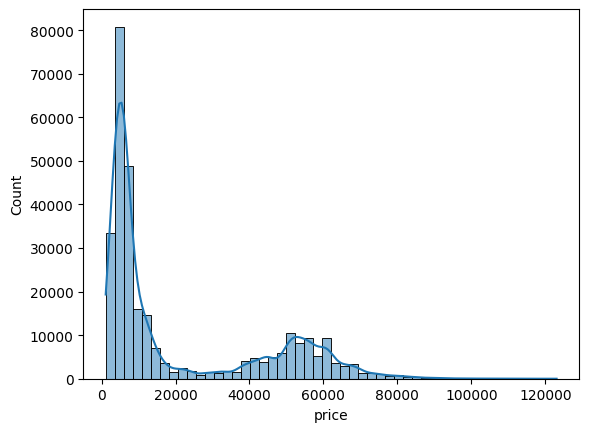

In [5]:
sns.histplot(data["price"], bins=50, kde=True)

In [6]:
numerical_cols = ["duration", "days_left"]

data[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
duration,300153.0,12.221021,7.191997,0.83,6.83,11.25,16.17,49.83
days_left,300153.0,26.004751,13.561004,1.00,15.00,26.00,38.00,49.00


In [7]:
categorical_cols = ["airline", "flight", "source_city", "destination_city", "class", "departure_time", "arrival_time",
                    "stops"]

data[categorical_cols].describe().T

,count,unique,top,freq
airline,300153,6,Vistara,127859
flight,300153,1561,UK-706,3235
source_city,300153,6,Delhi,61343
destination_city,300153,6,Mumbai,59097
class,300153,2,Economy,206666
departure_time,300153,6,Morning,71146
arrival_time,300153,6,Night,91538
stops,300153,3,one,250863


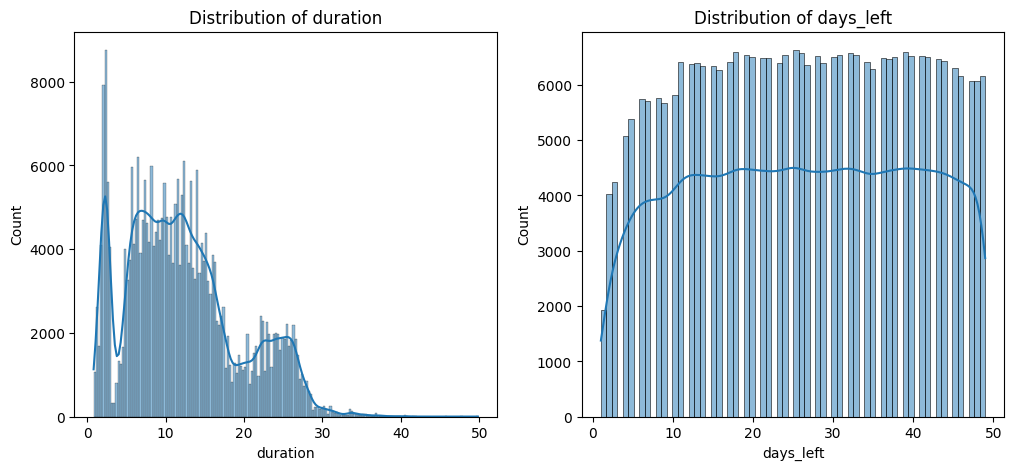

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for ax, col in zip(axs.ravel(), numerical_cols):
    sns.histplot(data[col], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')

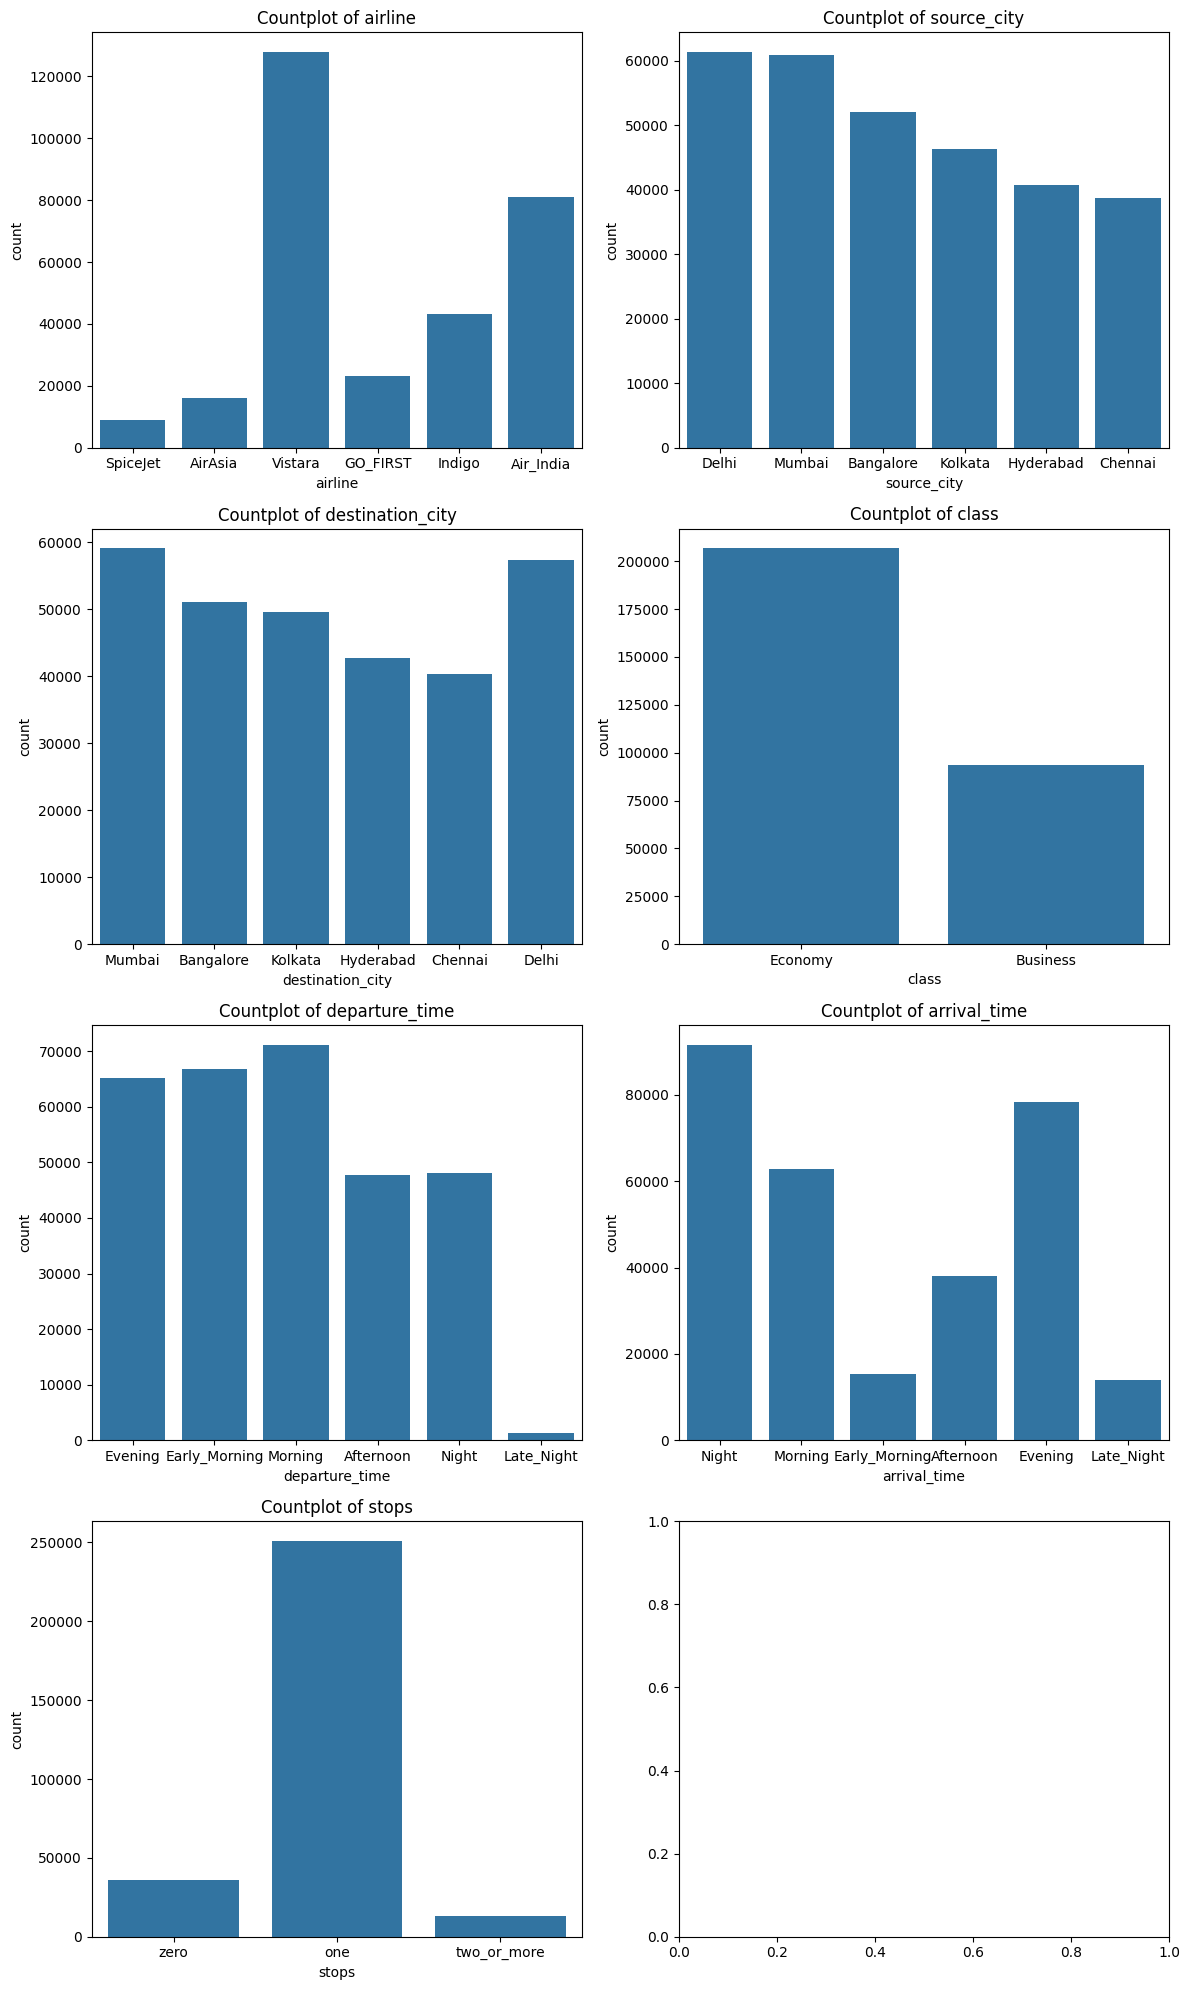

In [9]:
fig, axs = plt.subplots(4, 2, figsize=(12, 20))
cols = [c for c in categorical_cols if c != "flight"]

for ax, col in zip(axs.ravel(), cols):
    sns.countplot(data=data, x=col, ax=ax)
    ax.set_title(f'Countplot of {col}')

plt.tight_layout()


## Preprocessing

For this dataset, we will perform the following preprocessing steps:
- One-hot encode categorical features (airline, source_city, destination_city).
- Apply standard scaling to numerical features (duration, days_left).
- Ordinal-encode ordinal features (departure_time, arrival_time, stops, class).
- Drop flight column; it has very high cardinality, and it is related to airline, source_city and destination_city features.
- For the target column, divide it by 100 to make the values more manageable for the model and for end user interpretability. Since the prices are expressed in Indian Rupees, this will roughly convert the prices to USD, which is more familiar to a wider audience.

In [10]:
x_train, x_test, y_train, y_testval = train_test_split(
    data.drop(columns=["price", "flight"]),
    data["price"],
    test_size=0.3,
    random_state=42,
)

x_test, x_val, y_test, y_val = train_test_split(
    x_test,
    y_testval,
    test_size=0.5,
    random_state=42,
)

To ensure consistent encoding, we first create a list of known categories for each categorical feature. We will use this to:
- Ensure that columns that share a common set of categories (e.g., departure_time and arrival_time) are encoded consistently.
- Enforce an order for ordinal features.

In [11]:
airline_categories = list(data['airline'].unique())
city_categories = list(set(data['source_city'].unique()).union(set(data['destination_city'].unique())))

stops_categories = ["zero", "one", "two_or_more"]
class_categories = ["Economy", "Business"]
flight_time_categories = ["Early_Morning", "Morning", "Afternoon", "Evening", "Night", "Late_Night"]


In [12]:
preprocessing = make_pipeline(
    ColumnTransformer(
        transformers=[
            (
                "onehot",
                OneHotEncoder(categories=[airline_categories, city_categories, city_categories], drop="first"),
                ["airline", "source_city", "destination_city"],
            ),
            (
                "ordinal",
                OrdinalEncoder(
                    categories=[
                        flight_time_categories,
                        flight_time_categories,
                        stops_categories,
                        class_categories
                    ]
                ),
                ["departure_time", "arrival_time", "stops", "class"],
            ),
            (
                "scaler",
                StandardScaler(),
                ["duration", "days_left"],
            ),
        ]
    ))



In [13]:
x_train_preprocessed = preprocessing.fit_transform(x_train)
x_val_preprocessed = preprocessing.transform(x_val)
x_test_preprocessed = preprocessing.transform(x_test)

y_train_preprocessed = y_train / 100
y_val_preprocessed = y_val / 100
y_test_preprocessed = y_test / 100

Now, create our custom PyTorch dataset for training, validation, and testing.

In [14]:
class FlightPriceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).to(device)
        self.y = torch.tensor(y.values, dtype=torch.float32).view(-1, 1).to(device)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [15]:
train_data = FlightPriceDataset(x_train_preprocessed, y_train_preprocessed)
val_data = FlightPriceDataset(x_val_preprocessed, y_val_preprocessed)
test_data = FlightPriceDataset(x_test_preprocessed, y_test_preprocessed)

## Training Loop with Learning Curves

Let's start by creating our train function. It will handle training and will evaluate loss on the validation set at the end of each epoch.

In [24]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    """
    Train the model and record training and validation losses for each epoch.
    Note that the input model will be mutated.
    For each epoch, loss is averaged across
    :return: Two lists: training_losses and validation_losses.
    """

    for epoch in range(_num_epochs):
        _model.train()
        running_loss = 0.0
        for X_batch, y_batch in tqdm(_train_loader, desc=f"Epoch {epoch + 1}/{_num_epochs}"):
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            running_loss += loss.item() * X_batch.size(0)

        epoch_train_loss = running_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)

        epoch_val_loss = val_loss / len(_val_loader.dataset)
        print(f"epoch {epoch+1} loss: {epoch_train_loss:.2f} (train) | {epoch_val_loss:.2f} (val)")

    return [], []

For this exercise, we will intentionally cause overfitting by using a small subset of the training data, a relatively complex model, and training for more epochs than needed. This will allow us to see the characteristic learning curves of an overfitting model, where the training loss decreases while the validation loss starts to increase after a certain point.

In [25]:
train_subset = torch.utils.data.Subset(train_data, indices=range(500))

model = nn.Sequential(
    nn.Linear(train_data.X.shape[1], 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 1)
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 50
batch_size = 64

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size)

train_losses, val_losses = train(model, train_loader, val_loader, criterion, optimizer, num_epochs)

Epoch 1/50: 100%|██████████| 8/8 [00:00<00:00, 351.31it/s]


epoch 1 loss: 98483.96 (train) | 92447.79 (val)


Epoch 2/50: 100%|██████████| 8/8 [00:00<00:00, 564.39it/s]


epoch 2 loss: 94949.32 (train) | 86007.63 (val)


Epoch 3/50: 100%|██████████| 8/8 [00:00<00:00, 579.22it/s]


...

epoch 48 loss: 2108.69 (train) | 3291.14 (val)


Epoch 49/50: 100%|██████████| 8/8 [00:00<00:00, 615.14it/s]


epoch 49 loss: 2135.75 (train) | 3207.22 (val)


Epoch 50/50: 100%|██████████| 8/8 [00:00<00:00, 555.56it/s]


epoch 50 loss: 2043.15 (train) | 3198.49 (val)


Let's now define the function to plot the learning curves for training and validation loss.

In [18]:
def plot_learning_curves(_train_losses, _val_losses):
    pass

In [19]:
plot_learning_curves(train_losses, val_losses)

## Final Evaluation

Finally, we will evaluate the model on the test set to see how it performs on unseen data.

In [20]:
test_loader = DataLoader(test_data, batch_size=batch_size)

test_loss_batch = 0.0
with torch.no_grad():
    for X_val, y_test in test_loader:
        test_outputs = model(X_val)
        test_loss_batch += criterion(test_outputs, y_test).item() * X_val.size(0)

test_loss = test_loss_batch / len(test_loader.dataset)
print(f"Test Loss (MSE): {test_loss:.4f}")
print(
    f"A prediction made by this model will be off by roughly {math.sqrt(test_loss) * 100:.2f} Rupees (about {math.sqrt(test_loss):.2f} USD) from the actual price on average.")

Test Loss (MSE): 3284.3614
A prediction made by this model will be off by roughly 5730.93 Rupees (about 57.31 USD) from the actual price on average.
